# Relatorio de teste com logs Sysmon
Execute as celulas em ordem para gerar metricas, SHAP/LIME e o relatorio final.

In [40]:
import os
import sys
import subprocess
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import ipaddress
import joblib
import matplotlib.pyplot as plt

def ensure_package(import_name, pip_name=None):
    try:
        __import__(import_name)
        return
    except Exception:
        pkg = pip_name or import_name
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

ensure_package("Evtx", "python-evtx")
ensure_package("shap")
ensure_package("lime")

from Evtx.Evtx import Evtx
import xml.etree.ElementTree as ET
import shap
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings("ignore")

In [41]:
ROOT = Path("..").resolve()
MODEL_PATH = ROOT / "Train" / "modelo_ransomware.joblib"
DATASET_PATH = ROOT / "Datasets" / "LMD-2023-dataset.csv"
LOGS_DIR = ROOT / "RansomwaresLogs"

assert MODEL_PATH.exists(), f"Model not found: {MODEL_PATH}"
assert DATASET_PATH.exists(), f"Dataset not found: {DATASET_PATH}"
assert LOGS_DIR.exists(), f"Logs dir not found: {LOGS_DIR}"

rf = joblib.load(MODEL_PATH)
rf

RandomForestClassifier(class_weight='balanced', n_estimators=500, n_jobs=-1,
                       random_state=42)

In [42]:
import joblib
import sys
sys.path.append('..')
from parser.feature_engineering import extract_behavioral_features

df_train_raw = pd.read_csv(DATASET_PATH, low_memory=False)
df_train_raw = df_train_raw[df_train_raw['Label'] != 2].copy()

print('Extracting baseline behavioral features...')
df_train_behavioral = extract_behavioral_features(df_train_raw)
X_train = df_train_behavioral.drop(columns=['Label', 'ProcessId', '_log_file'], errors='ignore')

scaler = joblib.load(ROOT / 'Train' / 'preprocessor.joblib')
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)


2026-05-26 22:32:07,675 - INFO - Starting feature engineering (extracting behavioral features)


Extracting baseline behavioral features...


2026-05-26 22:32:14,598 - INFO - Extracted features for 2335 unique processes


In [43]:
import sys
sys.path.append('..')
from parser.evtx_parser import parse_all_evtx

print('Parsing all EVTX files...')
df_logs_raw = parse_all_evtx(LOGS_DIR)
print('events:', len(df_logs_raw), 'columns:', len(df_logs_raw.columns))

df_logs = extract_behavioral_features(df_logs_raw)
df_logs.head()


2026-05-26 22:32:14,615 - INFO - Found 2 EVTX files in C:\Projetos\RansonwareData\RansomwaresLogs
2026-05-26 22:32:14,616 - INFO - Parsing cerber.evtx...


Parsing all EVTX files...


2026-05-26 22:32:16,953 - INFO - Parsing wannacry.evtx...
2026-05-26 22:32:17,661 - INFO - Parsed 588 total events.
2026-05-26 22:32:17,664 - INFO - Starting feature engineering (extracting behavioral features)
2026-05-26 22:32:17,723 - INFO - Extracted features for 57 unique processes


events: 588 columns: 47


,ProcessId,total_events,events_per_second,num_created_processes,num_created_files,num_registry_modifications,num_network_connections,num_dns_queries,num_unique_ips,num_unique_ports,suspicious_extensions,Label
0,316,1,1.000000,1,0,0,0,0,0,0,0,-1
1,464,1,1.000000,1,0,0,0,0,0,0,0,-1
2,512,446,8.376373,1,445,0,0,0,0,0,0,-1
3,592,1,1.000000,1,0,0,0,0,0,0,0,-1
4,1248,1,1.000000,1,0,0,0,0,0,0,0,-1


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score

X_logs = df_logs.drop(columns=['Label', 'ProcessId', '_log_file'], errors='ignore')
# Align missing columns with train features
for col in X_train.columns:
    if col not in X_logs.columns:
        X_logs[col] = 0
X_logs = X_logs[X_train.columns]
X_logs_scaled = pd.DataFrame(scaler.transform(X_logs), columns=X_logs.columns)

pred_original = rf.predict(X_logs_scaled)
classes = list(getattr(rf, 'classes_', [0, 1]))
pos_label = 1 if 1 in classes else classes[-1]

if hasattr(rf, 'predict_proba'):
    prob = rf.predict_proba(X_logs_scaled)
    pos_index = classes.index(pos_label) if pos_label in classes else 0
    prob_pos = prob[:, pos_index]
else:
    prob_pos = np.full(len(pred_original), np.nan)

threshold = 0.15
pred = np.where(prob_pos > threshold, pos_label, 0)

df_logs['pred_label'] = pred
df_logs['prob_ransomware'] = prob_pos

# Print summary
summary = df_logs.groupby('ProcessId').agg(
    total_events=('total_events', 'mean'),
    predicted_ransomware_rate=('pred_label', lambda x: float(np.mean(x == pos_label))),
    avg_prob_ransomware=('prob_ransomware', 'mean'),
    max_prob_ransomware=('prob_ransomware', 'max')
).reset_index()

print('Predicao por Processo (Ransomware se Prob > 0.15):')
summary['log_pred_label'] = np.where(summary['avg_prob_ransomware'] > threshold, pos_label, 0)
print(summary)


KeyError: '_log_file'

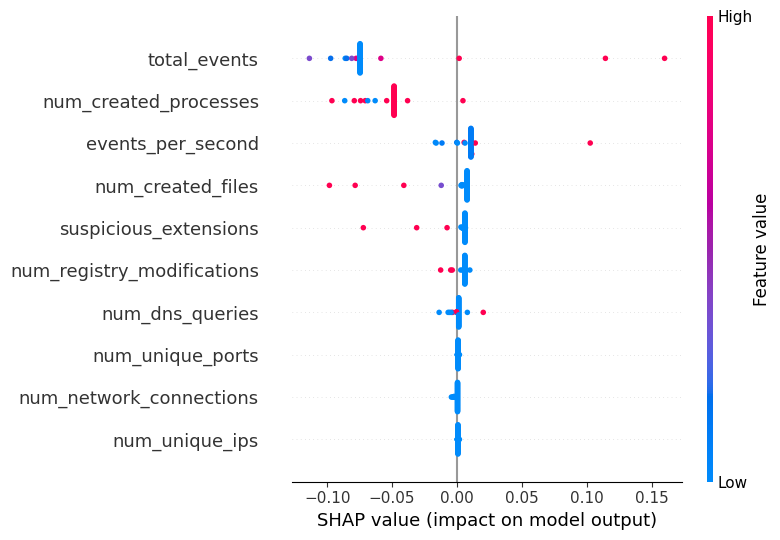

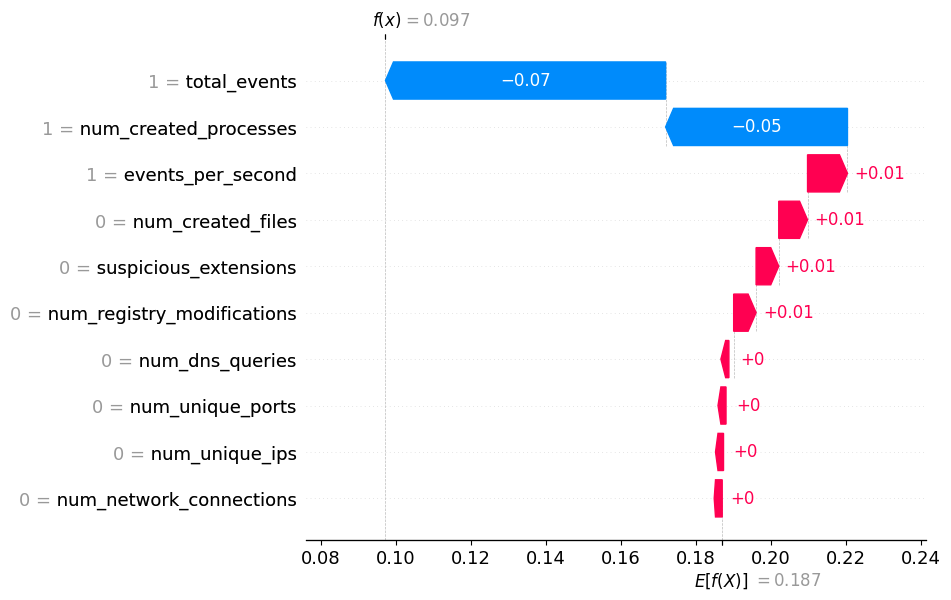

In [ ]:
sample_logs = X_logs.sample(n=min(200, len(X_logs)), random_state=42)
train_sample = X_train.sample(n=min(5000, len(X_train)), random_state=42)

explainer = shap.TreeExplainer(rf, data=train_sample)
sv_all = explainer.shap_values(sample_logs)

if isinstance(sv_all, list):
    pos_index = classes.index(pos_label) if pos_label in classes else 0
    sv = sv_all[pos_index]
elif isinstance(sv_all, np.ndarray) and sv_all.ndim == 3:
    pos_index = classes.index(pos_label) if pos_label in classes else 0
    sv = sv_all[:, :, pos_index]
else:
    sv = sv_all

shap.summary_plot(sv, sample_logs, show=True)
plt.show()

instance_idx = 0
sv_row = sv[instance_idx] if hasattr(sv, "__getitem__") else np.array(sv)[instance_idx]
row = sample_logs.iloc[instance_idx]
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = np.array(base_value).ravel()
    base_value = float(base_value[pos_index]) if len(base_value) > pos_index else float(base_value[0])
else:
    base_value = float(base_value)

try:
    exp = shap.Explanation(
        values=sv_row,
        base_values=base_value,
        data=row.values,
        feature_names=sample_logs.columns.tolist(),
    )
    shap.plots.waterfall(exp, max_display=12)
    plt.show()
except Exception as e:
    print("waterfall failed:", e)

[('total_events <= 8.00', -0.15124738930267276), ('num_created_processes <= 1.00', -0.06489235011388395), ('events_per_second > 0.03', 0.05170371893361612), ('num_registry_modifications <= 0.00', 0.047603080155014035), ('suspicious_extensions <= 0.00', 0.028622267688689675), ('num_unique_ips <= 1.00', 0.026273689036430545), ('num_created_files <= 0.00', 0.026030645477760694), ('num_network_connections <= 0.00', -0.020810102609813752), ('num_dns_queries <= 0.00', 0.010538528281684426), ('num_unique_ports <= 1.00', 0.010116068159760528)]


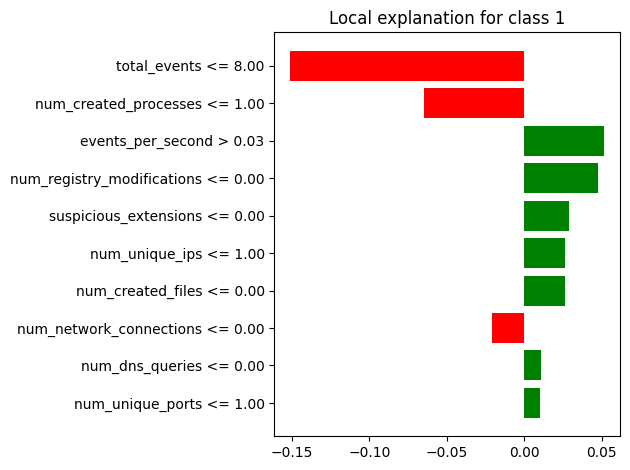

,feature,contribution
0,total_events <= 8.00,-0.151247
1,num_created_processes <= 1.00,-0.064892
2,events_per_second > 0.03,0.051704
3,num_registry_modifications <= 0.00,0.047603
4,suspicious_extensions <= 0.00,0.028622
5,num_unique_ips <= 1.00,0.026274
6,num_created_files <= 0.00,0.026031
7,num_network_connections <= 0.00,-0.020810
8,num_dns_queries <= 0.00,0.010539
9,num_unique_ports <= 1.00,0.010116


In [ ]:

# Garantir float
X_train = X_train.astype(float)
X_logs = X_logs.astype(float)

# Remover NaN e inf
X_train = X_train.replace([np.inf, -np.inf], 0).fillna(0)
X_logs = X_logs.replace([np.inf, -np.inf], 0).fillna(0)

instance_idx = 0
lime_explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=[str(c) for c in classes],
    mode="classification",
)

exp = lime_explainer.explain_instance(
    X_logs.iloc[instance_idx].values,
    rf.predict_proba,
    num_features=10,
)

print(exp.as_list())
fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

df_lime = pd.DataFrame(exp.as_list(), columns=["feature", "contribution"])
df_lime

In [ ]:

REPORT_DIR = ROOT / "Tests" / "Reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

pred_path = REPORT_DIR / "predictions_by_event.csv"
summary_path = REPORT_DIR / "summary_by_log.csv"
report_path = REPORT_DIR / "report.md"
dataset_path = REPORT_DIR / "logs_dataset_for_predict.csv"

# Save raw predictions
df_logs.to_csv(pred_path, index=False)

# Save summary
summary.to_csv(summary_path, index=False)

# Save processed dataset used for prediction
dataset_for_predict = X_logs.copy()

if "_log_file" in df_logs.columns:
    dataset_for_predict.insert(
        0,
        "_log_file",
        df_logs["_log_file"].values
    )

dataset_for_predict.to_csv(dataset_path, index=False)

# -----------------------------
# Build markdown report
# -----------------------------

report_lines = []

report_lines.append("# Sysmon Behavioral Ransomware Detection Report")
report_lines.append("")

report_lines.append("## General Information")
report_lines.append("")

report_lines.append(f"- Total processed logs: {len(summary)}")
report_lines.append(f"- Total analyzed events: {len(df_logs)}")
report_lines.append(f"- Detection threshold: {threshold}")
report_lines.append("")

# Optional metrics
if "Label" in df_logs.columns:

    valid_labels = df_logs["Label"].isin([0, 1])

    if valid_labels.any():

        from sklearn.metrics import (
            accuracy_score,
            recall_score,
            precision_score,
            f1_score
        )

        y_true = df_logs.loc[valid_labels, "Label"]
        y_pred_eval = df_logs.loc[valid_labels, "pred_label"]

        acc = accuracy_score(y_true, y_pred_eval)
        rec = recall_score(y_true, y_pred_eval)
        prec = precision_score(y_true, y_pred_eval)
        f1 = f1_score(y_true, y_pred_eval)

        report_lines.append("## Evaluation Metrics")
        report_lines.append("")
        report_lines.append(f"- Accuracy: {acc:.4f}")
        report_lines.append(f"- Precision: {prec:.4f}")
        report_lines.append(f"- Recall: {rec:.4f}")
        report_lines.append(f"- F1-score: {f1:.4f}")
        report_lines.append("")

# Prediction summary
report_lines.append("## Prediction Summary by Log")
report_lines.append("")

for _, row in summary.iterrows():

    label_txt = (
        "RANSOMWARE"
        if row["log_pred_label"] == pos_label
        else "BENIGN"
    )

    report_lines.append(
        f"### {row['_log_file']}"
    )

    report_lines.append(
        f"- Classification: **{label_txt}**"
    )

    report_lines.append(
        f"- Avg ransomware probability: "
        f"{row['avg_prob_ransomware']:.4f}"
    )

    report_lines.append(
        f"- Max ransomware probability: "
        f"{row['max_prob_ransomware']:.4f}"
    )

    report_lines.append(
        f"- Ransomware event ratio: "
        f"{row['predicted_ransomware_rate']:.4f}"
    )

    report_lines.append(
        f"- Total events: "
        f"{int(row['total_events'])}"
    )

    report_lines.append("")

# Save top suspicious processes/events
if "prob_ransomware" in df_logs.columns:

    top_suspicious = df_logs.sort_values(
        by="prob_ransomware",
        ascending=False
    ).head(10)

    report_lines.append("## Top Suspicious Processes")
    report_lines.append("")

    cols_to_show = [
        c for c in [
            "_log_file",
            "ProcessKey",
            "Image",
            "prob_ransomware",
            "events_per_second",
            "total_events"
        ]
        if c in top_suspicious.columns
    ]

    report_lines.append(
        top_suspicious[cols_to_show].to_string(index=False)
    )

    report_lines.append("")

# Generated files
report_lines.append("## Generated Files")
report_lines.append("")

report_lines.append(f"- Predictions CSV: `{pred_path}`")
report_lines.append(f"- Summary CSV: `{summary_path}`")
report_lines.append(f"- Dataset CSV: `{dataset_path}`")

# Save markdown report
report_path.write_text(
    "\n".join(report_lines),
    encoding="utf-8"
)

print("Report saved:", report_path)

report_path

KeyError: '_log_file'

In [ ]:
# Dataset com campo predict
predict_path = REPORT_DIR / "logs_dataset_with_predict.csv"

dataset_with_predict = dataset_for_predict.copy()
if "pred_label" in df_logs.columns:
    dataset_with_predict["predict"] = df_logs["pred_label"].values
else:
    dataset_with_predict["predict"] = pd.Series([None] * len(dataset_with_predict))
    print("pred_label column not found in df_logs")

dataset_with_predict.to_csv(predict_path, index=False)
print("Dataset with predict saved:", predict_path)


Dataset with predict saved: C:\Projetos\RansonwareData\Tests\Reports\logs_dataset_with_predict.csv


In [ ]:
# Count total events and group by EventID
print("Total events:", len(df_logs))

if "EventID" in df_logs.columns:
    event_counts = df_logs["EventID"].value_counts().sort_index()
    display(event_counts)
else:
    print("EventID column not found in df_logs")

Total events: 117
EventID column not found in df_logs


In [ ]:
# Dataset com resultados dos logs + groupby EventID
results_path = REPORT_DIR / "logs_results_dataset.csv"

cols = [c for c in ["_log_file", "EventID", "pred_label", "prob_ransomware"] if c in df_logs.columns]
df_results = df_logs[cols].copy()
df_results.to_csv(results_path, index=False)
print("Results dataset saved:", results_path)

if "EventID" in df_results.columns:
    event_counts_results = df_results["EventID"].value_counts().sort_index()
    display(event_counts_results)
else:
    print("EventID column not found in df_results")

Results dataset saved: C:\Projetos\RansonwareData\Tests\Reports\logs_results_dataset.csv
EventID column not found in df_results


In [ ]:
# Checagem de linhas com pred_label=1 (ransomware)
if "pred_label" in df_logs.columns:
    ransomware_count = int((df_logs["pred_label"] == 1).sum())
    total_count = int(len(df_logs))
    print(f"ransomware_count: {ransomware_count} / {total_count}")
    if ransomware_count == 0:
        print("Nenhuma linha com pred_label=1 no df_logs.")
else:
    print("pred_label column not found in df_logs")


ransomware_count: 15 / 117


In [ ]:
import json
sample_train = df_train.head(2).to_dict(orient="records")
sample_test = X_logs.head(2).to_dict(orient="records")

diff_cols = set(X_train_raw.columns) - set(df_logs.columns)
print(f"Columns in X_train_raw but NOT in df_logs: {len(diff_cols)}")
for c in list(diff_cols)[:10]:
    print(c)


NameError: name 'df_train' is not defined

In [ ]:
print("Sample 1 from Train dataset (first 10 features):")
sample_train = df_train[X_train_raw.columns].iloc[0]
print(sample_train.head(10))

print("\nSample 1 from df_logs (EVTX) (first 10 features):")
print(df_logs[df_logs.columns[:10]].iloc[0])

print("\nValue formatting differences (ProcessID vs Execution_ProcessID):")
if "Execution_ProcessID" in X_train_raw.columns:
    print("Train Execution_ProcessID:", df_train["Execution_ProcessID"].iloc[0])
if "ProcessID" in df_logs.columns:
    print("EVTX ProcessID:", df_logs["ProcessID"].iloc[0])


Sample 1 from Train dataset (first 10 features):


NameError: name 'df_train' is not defined

In [ ]:
df_train_num = X_train_raw.select_dtypes(include=["int64", "float64"]).columns
df_logs_num = df_logs.select_dtypes(include=["int64", "float64"]).columns

print("Train numerical columns:", list(df_train_num))
print("Test (EVTX) numerical columns:", list(df_logs_num))

print("\nMissing cols filled with default (in X_logs):")
missing_in_test = [c for c in X_train_raw.columns if c not in df_logs.columns]
print(missing_in_test)


NameError: name 'X_train_raw' is not defined

In [ ]:
# Analisando especificamente os logs do Cerber com o novo modelo

df_cerber = df_logs[df_logs["_log_file"] == "cerber.evtx"]
X_cerber = X_logs[df_logs["_log_file"] == "cerber.evtx"]

print(f"Total Cerber events: {len(df_cerber)}")
print(f"Predicted as Ransomware: {(df_cerber['pred_label'] == 1).sum()}")

sample_cerber = X_cerber.iloc[0:2]

explainer_cerber = shap.TreeExplainer(rf)
sv_cerber = explainer_cerber.shap_values(sample_cerber)
if isinstance(sv_cerber, list):
    sv_cerber = sv_cerber[1] 
elif len(sv_cerber.shape) == 3:
    sv_cerber = sv_cerber[:, :, 1]

for i in range(len(sample_cerber)):
    print(f"\n--- Cerber Event {i} ---")
    print("Prob Ransomware:", df_cerber.iloc[i]["prob_ransomware"])
    print("EventID:", df_cerber.iloc[i].get("EventID", "N/A"))
    print("Image:", df_cerber.iloc[i].get("Image", "N/A"))
    
    contributions = sv_cerber[i]
    neg_idx = contributions.argsort()[:3]
    print("Top factors DECREASING ransomware probability (SHAP):")
    for idx in neg_idx:
        fname = X_logs.columns[idx]
        val = sample_cerber.iloc[i][fname]
        impact = contributions[idx]
        print(f"  {fname}={val} (impact: {impact:.4f})")


KeyError: '_log_file'